In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from tqdm import tqdm
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

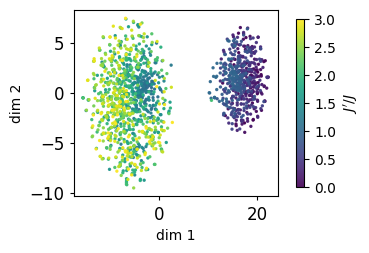

In [14]:
g = 0.96
d = 25
delta = 1.0

df = pd.read_csv(f'data/eSSH/128_p_p/g{g}_d{d}_{delta}_.csv')
data = df.to_numpy()
data = data.T
colors = np.linspace(0, 3, data.shape[0])

tsne = TSNE(n_components=2, random_state=0)
data_2d = tsne.fit_transform(data[:,:])

fig, ax = plt.subplots(figsize=(3.39, 2.36))  # 单栏尺寸

sc = ax.scatter(
    data_2d[:, 0],
    data_2d[:, 1],
    c=colors,
    vmin=0.0,
    vmax=3.0,
    s=2,
    alpha=0.9
)

# colorbar 细一点、紧凑一点
cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.07, aspect=20)
cbar.set_alpha(1)
cbar.set_label(r"$J'/J$")

ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
# 保留坐标轴刻度文字
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# 去除坐标轴主刻度线
ax.tick_params(axis='both', which='both', length=3, width=0.8, labelsize=12)
# 紧凑布局
plt.tight_layout(pad=0.1)
plt.savefig(f'figs/eSSH_128_p_p_g{g}_d{d}_{delta}_tsne.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

[[6.4326744e-09 1.0000000e+00]
 [2.5883065e-08 1.0000000e+00]
 [2.2280862e-09 1.0000000e+00]
 ...
 [1.0000000e+00 1.1831593e-11]
 [1.0000000e+00 4.2354035e-28]
 [1.0000000e+00 3.2323341e-26]]


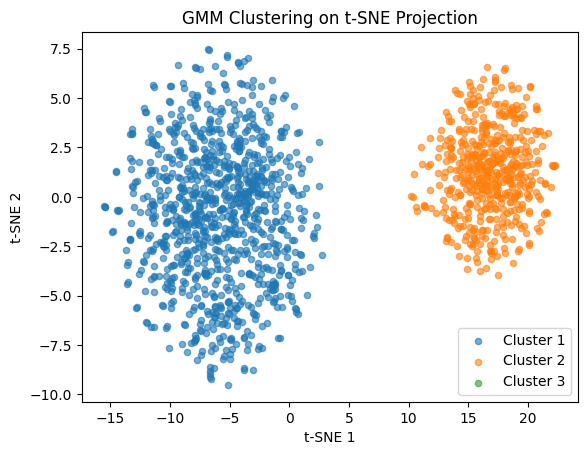

In [15]:
df = pd.read_csv(f'data/eSSH/128_p_p/g{g}_d{d}_{delta}_.csv')
data = df.to_numpy()
data = data.T
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data_2d)
labels = gmm.predict(data_2d)
probs = gmm.predict_proba(data_2d)
print(probs)
for i in range(3):
    cluster_data = data_2d[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i+1}', s=20, alpha=0.6)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("GMM Clustering on t-SNE Projection")
plt.legend()
plt.show()

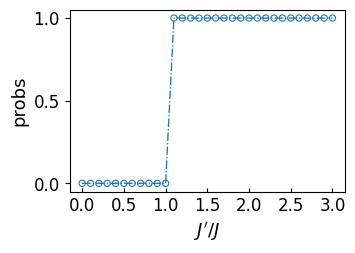

In [16]:
# 画 GMM 概率分布，适合 revtex 单栏，稀疏空心点+虚线，y轴刻度仅0,0.5,1，scatter单色且更稀疏，xticks更密集
fig, ax = plt.subplots(figsize=(3.39, 2.36))
# 选用更美观的单色（如深蓝）
scatter_color = '#1f77b4'  # matplotlib 默认蓝色
# 稀疏采样，1/50
step = max(1, len(colors)//(len(colors)//50 if len(colors)//50>0 else 1))
idx = np.arange(0, len(colors), step)
# 空心点：facecolor完全透明，edgecolor为单色
ax.scatter(colors[idx], probs[idx,0], facecolors='none', edgecolors=scatter_color, linewidths=0.8, s=20, zorder=2)
# 用虚线穿过所有点，颜色同scatter
ax.plot(colors[idx], probs[idx,0], linestyle='-.', color=scatter_color, linewidth=0.95, zorder=1)
ax.set_xlabel(r"$J'/J$", fontsize=13)
ax.set_ylabel("probs", fontsize=13)
# 设置y轴刻度为0, 0.5, 1，保留一位小数
ax.set_yticks([0.0, 0.5, 1.0])
ax.set_yticklabels(["0.0", "0.5", "1.0"], fontsize=12)
# 设置x轴刻度更密集（如0.0到3.0每0.5）
ax.set_xticks(np.arange(0, 3.01, 0.5))
ax.set_xticklabels([f"{x:.1f}" for x in np.arange(0, 3.01, 0.5)], fontsize=12)
# 保留x轴刻度，字体更大
ax.tick_params(axis='x', which='both', direction='in', length=3, width=0.8, labelsize=12)
# 紧凑布局
plt.tight_layout(pad=0.1)
plt.savefig(f'figs/gmm_prob_eSSH_128_p_p_g{g}_d{d}_{delta}.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

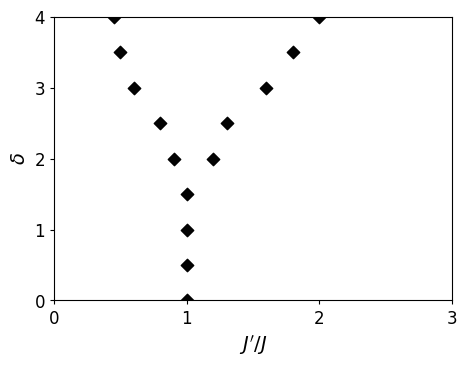

In [30]:
# 方框用于画相图，横坐标为J'/J，纵坐标为δ，并标出指定蓝色菱形点
fig, ax = plt.subplots(figsize=(4.5, 3.5))  # 加宽宽度
ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_xlim(0, 3)
ax.set_ylim(0, 4)
# 设置坐标轴标签
ax.set_xlabel(r"$J'/J$", fontsize=14)
ax.set_ylabel(r"$\delta$", fontsize=14)
# 只保留边框和刻度
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.tick_params(axis='both', which='both', direction='out', length=3, width=0.8, labelsize=12)
# 标出指定点，蓝色菱形
points = [(1, 0.0), (1, 0.5), (1, 1.0), (1, 1.5), (0.9, 2.0), (1.2, 2.0), (0.8, 2.5), (1.3, 2.5), (0.6, 3.0), (1.6, 3.0), (0.5, 3.5), (1.8, 3.5), (0.45, 4.0), (2.0, 4.0)]
xs, ys = zip(*points)
ax.scatter(xs, ys, marker='D', color='black', s=40, alpha=0.99, zorder=3)
plt.tight_layout(pad=0.1)
plt.savefig("figs/phase.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

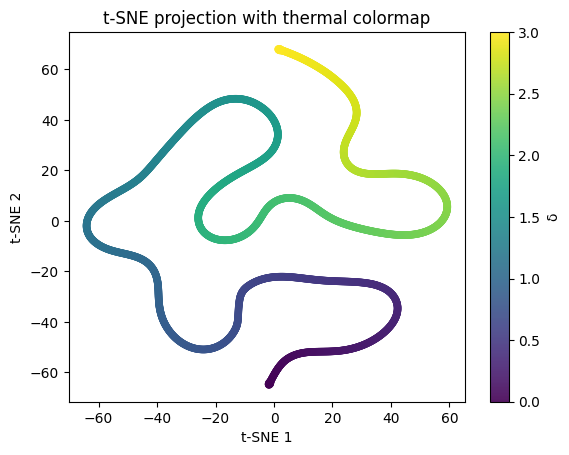

In [ ]:
from sklearn.decomposition import KernelPCA
df = pd.read_csv('data/eSSH_identity/128_p_p/3.0_results.csv')
data = df.to_numpy()
data = data.T
colors = np.linspace(0, 3, data.shape[0])

tsne = TSNE(n_components=2, random_state=42)
data_2d_0 = tsne.fit_transform(data)
# 把 scatter 返回的对象保存到 sc
sc = plt.scatter(
    data_2d_0[:, 0],
    data_2d_0[:, 1],
    c=colors,
    # cmap="inferno",   # 你想要 thermal 配色的话，可以换 "hot" 或 "plasma"
    vmin=0.0,
    vmax=3.0,
    s=20,
    alpha=0.9
)

# 用 sc 生成 colorbar
cbar = plt.colorbar(sc)
cbar.set_alpha(1)   # 强制 colorbar 不透明
cbar.set_label("δ")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection with thermal colormap")
plt.show()

In [ ]:
plt.scatter(colors, probs[:,0], c=colors, vmin=0.0, vmax=3.0, s=20, alpha=0.9)

[[9.3562785e-04 2.1864167e-05 9.9904293e-01]
 [9.3181041e-04 2.2140024e-05 9.9904585e-01]
 [9.5462205e-04 2.1820506e-05 9.9902385e-01]
 ...
 [5.2327938e-02 9.4767171e-01 4.4781710e-14]
 [5.1835369e-02 9.4816428e-01 4.0455124e-14]
 [5.2182719e-02 9.4781721e-01 4.1465634e-14]]


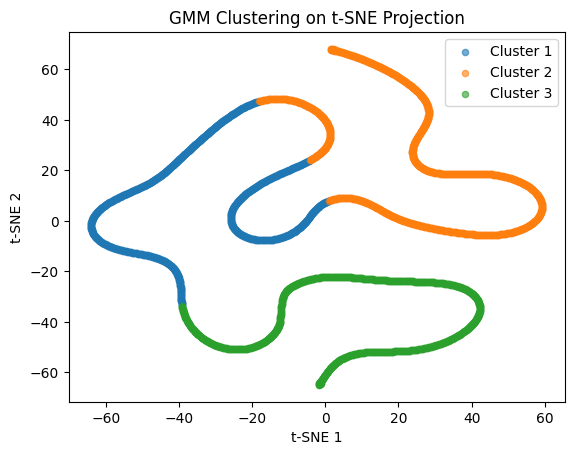

In [ ]:

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(data_2d_0)
labels = gmm.predict(data_2d_0)
probs = gmm.predict_proba(data_2d_0)
print(probs)
for i in range(3):
    cluster_data = data_2d_0[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i+1}', s=20, alpha=0.6)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("GMM Clustering on t-SNE Projection")
plt.legend()
plt.show()

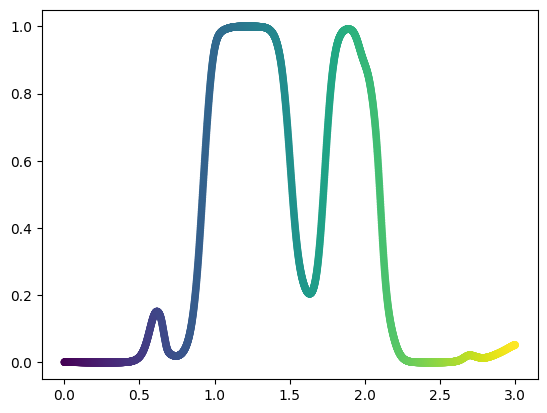

In [ ]:
plt.scatter(colors, probs[:,0], c=colors, vmin=0.0, vmax=3.0, s=20, alpha=0.9)

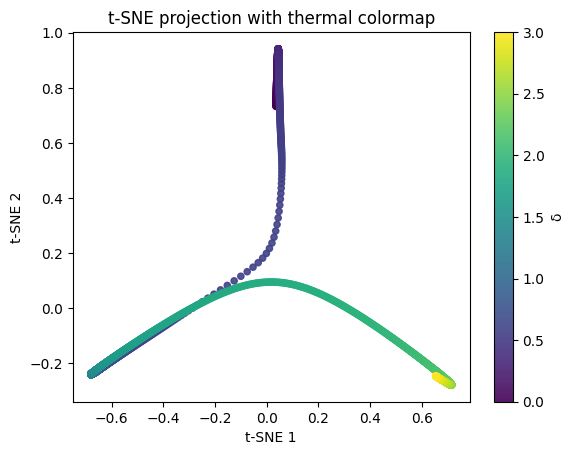

In [ ]:
from sklearn.decomposition import KernelPCA
df = pd.read_csv('data/eSSH_identity/128_p_p/3.5_results.csv')
data = df.to_numpy()
data = data.T
colors = np.linspace(0, 3, data.shape[0])

pca = PCA(n_components=2)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
data_2d = pca.fit_transform(data)
data_2d = kpca.fit_transform(data)
# 把 scatter 返回的对象保存到 sc
sc = plt.scatter(
    data_2d[:, 0],
    data_2d[:, 1],
    c=colors,
    # cmap="inferno",   # 你想要 thermal 配色的话，可以换 "hot" 或 "plasma"
    vmin=0.0,
    vmax=3.0,
    s=20,
    alpha=0.9
)

# 用 sc 生成 colorbar
cbar = plt.colorbar(sc)
cbar.set_alpha(1)   # 强制 colorbar 不透明
cbar.set_label("δ")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection with thermal colormap")
plt.show()

In [ ]:
data_2d

array([[-0.05295925,  0.06809888],
       [-0.0531896 ,  0.06850837],
       [-0.05342009,  0.06891848],
       ...,
       [ 0.42258204, -0.32543909],
       [ 0.42044999, -0.32402663],
       [ 0.41831968, -0.32261112]], shape=(3001, 2))

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.5_d10_0.5_.csv')
data = df.to_numpy()
data = data.T

In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

In [ ]:
plt.scatter(data_pca[:, 0], data_pca[:, 1], s=5)

In [ ]:
# t-SNE data
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,     # 降到二维
    perplexity=30,      # 每个点的近邻数目，常调参范围 5~50
    learning_rate=200,  # 学习率
    random_state=42
)

# 执行降维
data_2d = tsne.fit_transform(data)

# 可视化
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=20, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection")
plt.show()

In [ ]:
labels.shape

In [ ]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2, random_state=42, covariance_type='full')
gmm.fit(data)
labels = gmm.predict(data)
probs = gmm.predict_proba(data)
plt.scatter(np.linspace(0.0,3.001,len(labels)), labels, s=5)

In [ ]:
df = pd.read_csv('data/eSSH_identity/128_p_p/4.0_results.csv')
data = df.to_numpy()
data = data.T

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
gmm.fit(data)
labels = gmm.predict(data)
probs = gmm.predict_proba(data)
plt.scatter(np.linspace(0.0,3.001,len(labels)), labels, s=5)
plt.scatter(np.linspace(0,3.0,len(labels)), probs[:, 1], s=5)

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.84_d10_3.0_.csv')
data = df.to_numpy()
data = data.T

from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
gmm.fit(data)
labels = gmm.predict(data)
probs = gmm.predict_proba(data)
plt.scatter(np.linspace(0.0,3.001,len(labels)), labels, s=5)

In [ ]:
df = pd.read_csv('data/eSSH_identity/128_p_p/0.5_results.csv')
data = df.to_numpy()
data = data.T

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

plt.scatter(np.linspace(0.0,3.001,len(labels)), data_pca[:, 1], s=5)
plt.scatter(np.linspace(0.0,3.001,len(labels)), data_pca[:, 0], s=5)

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.5_d40_3.0_.csv')
data = df.to_numpy()
data = data.T

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

plt.scatter(np.linspace(0.0,3.001,len(data_pca[:,0])), data_pca[:, 0]/128, s=5)
plt.scatter(np.linspace(0.0,3.001,len(data_pca[:,1])), data_pca[:, 1]/128, s=5)
plt.show()

In [ ]:
df = pd.read_csv('data/eSSH_identity/128_p_p/3.0_results.csv')
data = df.to_numpy()
data = data.T

tsne = TSNE(n_components=2)
data_2d = tsne.fit_transform(data)
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=20, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection")
plt.show()

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.5_d40_3.0_.csv')
data = df.to_numpy()
data = data.T

tsne = TSNE(n_components=2)
data_2d = tsne.fit_transform(data)
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=20, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection")
plt.show()

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.84_d25_3.0_.csv')
data = df.to_numpy()
data = data.T

tsne = TSNE(n_components=2)
data_2d = tsne.fit_transform(data)
colors = np.arange(data.shape[0])
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=colors, s=20, alpha=0.6)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection")
plt.show()

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.96_d25_0.5_.csv')
data = df.to_numpy()
data = data.T
colors = np.arange(data.shape[0])

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(data)
# 把 scatter 返回的对象保存到 sc
sc = plt.scatter(
    data_2d[:, 0],
    data_2d[:, 1],
    c=colors,
    # cmap="inferno",   # 你想要 thermal 配色的话，可以换 "hot" 或 "plasma"
    vmin=0.0,
    vmax=3.0,
    s=20,
    alpha=0.9
)

# 用 sc 生成 colorbar
cbar = plt.colorbar(sc)
cbar.set_alpha(1)   # 强制 colorbar 不透明
cbar.set_label("δ")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection with thermal colormap")
plt.show()

# from sklearn.mixture import BayesianGaussianMixture
# dpgmm = BayesianGaussianMixture(
#     n_components=3,  # 最大可能簇数
#     covariance_type='full',
#     weight_concentration_prior_type='dirichlet_process',
#     max_iter=1000,
#     random_state=42
# )
# dpgmm.fit(data_2d)
# # 4️⃣ 获取聚类标签和每个样本的概率
# labels = dpgmm.predict(data_2d)                  # 每个样本所属簇
# probs = dpgmm.predict_proba(data_2d).max(axis=1) # 每个样本属于其簇的最大概率


In [ ]:
# 4️⃣ 绘图
labels = dpgmm.predict(data_2d)                  # 每个样本所属簇
probs = dpgmm.predict_proba(data_2d).max(axis=1) # 每个样本属于其簇的最大概率
plt.figure(figsize=(8,4))
sc = plt.scatter(
    colors,
    labels,
    c=colors,           # 用概率显示颜色
    cmap='viridis',
    s=50,
    edgecolors='k'
)
plt.xlabel("δ")
plt.ylabel("DPGMM Label")
plt.title("DPGMM labels vs δ")
cbar = plt.colorbar(sc)
cbar.set_label("Cluster probability")
plt.show()

In [ ]:
df = pd.read_csv('data/eSSH/128_p_p/g0.96_d25_3.0_.csv')
data = df.to_numpy()
data = data.T

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(data)
# 把 scatter 返回的对象保存到 sc
sc = plt.scatter(
    data_2d[:, 0],
    data_2d[:, 1],
    c=colors,
    # cmap="inferno",   # 你想要 thermal 配色的话，可以换 "hot" 或 "plasma"
    vmin=0.0,
    vmax=3.0,
    s=20,
    alpha=0.9
)

# 用 sc 生成 colorbar
cbar = plt.colorbar(sc)
cbar.set_alpha(1)   # 强制 colorbar 不透明
cbar.set_label("δ")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection with thermal colormap")
plt.show()

from sklearn.mixture import BayesianGaussianMixture
dpgmm = BayesianGaussianMixture(
    n_components=3,  # 最大可能簇数
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    max_iter=1000,
    random_state=42
)
dpgmm.fit(data_2d)
# 4️⃣ 获取聚类标签和每个样本的概率
labels = dpgmm.predict(data_2d)                  # 每个样本所属簇
probs = dpgmm.predict_proba(data_2d).max(axis=1) # 每个样本属于其簇的最大概率

In [ ]:
plt.figure(figsize=(8,4))
sc = plt.scatter(
    colors,
    labels,
    c=colors,           # 用概率显示颜色
    cmap='viridis',
    s=50,
    edgecolors='k'
)
plt.xlabel("δ")
plt.ylabel("DPGMM Label")
plt.title("DPGMM labels vs δ")
cbar = plt.colorbar(sc)
cbar.set_label("Cluster probability")
plt.show()

In [ ]:
# 5️⃣ 可视化
plt.figure(figsize=(8,6))
sc = plt.scatter(
    data_2d[:,0],
    data_2d[:,1],
    c=labels,           # 用簇 label 作为颜色
    cmap='tab10',       # 颜色表
    s=50,
    alpha=probs,        # 透明度表示归属概率
    edgecolors='k'
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("DPGMM clustering on t-SNE")

# 添加 colorbar 显示簇
cbar = plt.colorbar(sc, ticks=range(dpgmm.n_components))
cbar.set_label("Cluster label")

plt.show()
